In [6]:
from typing import Optional, Tuple
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn import ReLU

import matplotlib
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']  # 用于正常显示中文
plt.rcParams['axes.unicode_minus'] = False  # 用于正常显示负号

from pfhedge.instruments import BaseInstrument, EuropeanOption
from pfhedge.nn import BlackScholes, EntropicRiskMeasure, ExpectedShortfall, Hedger, MultiLayerPerceptron
from pfhedge.stochastic.local_volatility import generate_local_volatility_process
from pfhedge.instruments.primary.brownian import BrownianStock

In [7]:
class LocalVolatilityStock(BaseInstrument):
    """支持局部波动率的自定义股票类"""
    def __init__(self, cost: float = 0.0, dt: float = 1/250, sigma_fn=None):
        super().__init__()
        self.cost = cost
        self.dt = dt
        self.sigma_fn = sigma_fn
        # 直接作为属性存储，不使用 register_buffer
        self._spot = None
        self._volatility = None
        self._log_spot = None
        
    def to(self, device=None, dtype=None):
        """实现设备转移方法"""
        # 如果有数据，转移到指定设备
        if self._spot is not None:
            self._spot = self._spot.to(device=device, dtype=dtype)
        if self._volatility is not None:
            self._volatility = self._volatility.to(device=device, dtype=dtype)
        if self._log_spot is not None:
            self._log_spot = self._log_spot.to(device=device, dtype=dtype)
        return self
        
    @property
    def spot(self) -> torch.Tensor:
        """返回股价路径"""
        if self._spot is None:
            raise ValueError("Stock not yet simulated. Call simulate() first.")
        return self._spot
    
    @property
    def log_spot(self) -> torch.Tensor:
        """返回对数股价路径"""
        if self._log_spot is None:
            raise ValueError("Stock not yet simulated. Call simulate() first.")
        return self._log_spot
        
    def is_listed(self, time: float) -> bool:
        """检查股票在给定时间是否上市"""
        return True
        
    def simulate(self, n_paths: int, time_horizon: Optional[float] = None, 
                 init_state: Optional[Tuple[float, ...]] = None):
        """模拟股价路径"""
        if time_horizon is None:
            time_horizon = 30 * self.dt
        
        n_steps = int(time_horizon / self.dt)
        
        # 使用局部波动率模型生成路径
        spot, volatility = generate_local_volatility_process(
            n_paths, n_steps, self.sigma_fn, init_state, self.dt
        )
        
        # 直接存储为属性
        self._spot = spot
        self._volatility = volatility
        self._log_spot = spot.log()
        
        return self

    @property
    def volatility(self):
        """返回波动率路径"""
        if self._volatility is None:
            raise ValueError("Stock not yet simulated. Call simulate() first.")
        return self._volatility

    @property
    def sigma(self):
        """返回波动率（兼容性）"""
        return self.volatility

def create_lv_hedger(loss, derivative, features, n_epochs, n_paths, init_spot, sigma_fn):
    """创建并训练使用局部波动率数据的对冲器"""
    model = MultiLayerPerceptron(n_layers=4, n_units=[64, 32, 32, 16], activation=ReLU())
    hedger = Hedger(model, features, criterion=loss)
    
    print(f"  开始训练，总共 {n_epochs} 个 epochs...")
    
    # 手动训练循环，避免使用可能有问题的 fit 方法
    optimizer = torch.optim.Adam(hedger.parameters(), lr=0.001)
    
    for epoch in range(n_epochs):
        # 创建新的局部波动率股票
        lv_stock = LocalVolatilityStock(
            cost=derivative.underlier.cost,
            dt=derivative.underlier.dt,
            sigma_fn=sigma_fn
        )
        
        # 创建新的期权
        lv_derivative = EuropeanOption(lv_stock, 
                                     strike=derivative.strike, 
                                     maturity=derivative.maturity)
        
        # 模拟路径
        lv_derivative.simulate(n_paths=n_paths, init_state=(init_spot,))
        
        # 手动计算损失和更新
        hedger.train()
        
        # 计算对冲PnL
        pnl = compute_hedge_pnl_for_training(hedger, lv_derivative, features)
        
        # 计算损失
        loss_value = loss(pnl)
        
        # 反向传播和优化
        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()
        
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch + 1}/{n_epochs}, Loss: {loss_value.item():.6f}")
    
    hedger.eval()
    return hedger

def compute_hedge_pnl_for_training(hedger, derivative, feature_names):
    """训练时计算对冲PnL"""
    device = derivative.underlier.spot.device
    n_paths = derivative.underlier.spot.shape[0]
    n_steps = derivative.underlier.spot.shape[1] - 1
    
    # 初始化
    total_pnl = torch.zeros(n_paths, device=device)
    current_hedge = torch.zeros(n_paths, device=device)
    
    # 获取初始股票价格
    initial_spot = derivative.underlier.spot[:, 0]
    
    for step in range(n_steps):
        # 当前时间和股价
        time_to_expiry = derivative.maturity - step * derivative.underlier.dt
        current_spot = derivative.underlier.spot[:, step]
        current_vol = derivative.underlier.volatility[:, step]
        
        # 神经网络：使用真实的局部波动率作为输入
        feature_values = {
            "log_moneyness": (current_spot / derivative.strike).log(),
            "expiry_time": torch.full((n_paths,), time_to_expiry, device=device),
            "volatility": current_vol,
            "prev_hedge": current_hedge
        }
        # 构建输入
        input_features = torch.stack([feature_values[name] for name in feature_names], dim=1)
        new_hedge = hedger.model(input_features).squeeze()
        
        # 计算对冲成本
        if step == 0:
            total_pnl = total_pnl - new_hedge * initial_spot
        else:
            hedge_change = new_hedge - current_hedge
            total_pnl = total_pnl - hedge_change * current_spot
        
        current_hedge = new_hedge
    
    # 最终清算
    final_spot = derivative.underlier.spot[:, -1]
    option_payoff = (final_spot - derivative.strike).clamp(min=0)
    total_pnl = total_pnl + current_hedge * final_spot
    total_pnl = total_pnl - option_payoff
    
    return total_pnl

def compute_lv_pnl(hedger, derivative, feature_names, is_black_scholes=False):
    """计算使用局部波动率的对冲策略损益"""
    device = derivative.underlier.spot.device
    n_paths = derivative.underlier.spot.shape[0]
    n_steps = derivative.underlier.spot.shape[1] - 1
    
    # 初始化
    total_pnl = torch.zeros(n_paths, device=device)
    current_hedge = torch.zeros(n_paths, device=device)
    
    # 获取初始股票价格
    initial_spot = derivative.underlier.spot[:, 0]
    
    for step in range(n_steps):
        # 当前时间和股价
        time_to_expiry = derivative.maturity - step * derivative.underlier.dt
        current_spot = derivative.underlier.spot[:, step]
        current_vol = derivative.underlier.volatility[:, step]
        
        if is_black_scholes:
            # Black-Scholes 使用当前的局部波动率
            log_moneyness = (current_spot / derivative.strike).log()
            new_hedge = hedger.delta(log_moneyness, time_to_expiry, current_vol)
        else:
            # 神经网络：使用真实的局部波动率作为输入
            feature_values = {
                "log_moneyness": (current_spot / derivative.strike).log(),
                "expiry_time": torch.full((n_paths,), time_to_expiry, device=device),
                "volatility": current_vol,
                "prev_hedge": current_hedge
            }
            # 构建输入
            input_features = torch.stack([feature_values[name] for name in feature_names], dim=1)
            new_hedge = hedger.model(input_features).squeeze()
        
        # 计算对冲成本
        if step == 0:
            total_pnl -= new_hedge * initial_spot
        else:
            hedge_change = new_hedge - current_hedge
            total_pnl -= hedge_change * current_spot
        
        current_hedge = new_hedge
    
    # 最终清算
    final_spot = derivative.underlier.spot[:, -1]
    option_payoff = (final_spot - derivative.strike).clamp(min=0)
    total_pnl += current_hedge * final_spot
    total_pnl -= option_payoff
    
    return total_pnl

def create_gbm_hedger(loss, derivative, features, n_epochs, n_paths, init_spot, sigma):
    model = MultiLayerPerceptron(n_layers=4, n_units=[64, 32, 32, 16], activation=ReLU())
    hedger = Hedger(model, features, criterion=loss)
    optimizer = torch.optim.Adam(hedger.parameters(), lr=0.001)
    for epoch in range(n_epochs):
        # 创建新的GBM股票
        gbm_stock = BrownianStock(cost=derivative.underlier.cost, dt=derivative.underlier.dt, sigma=sigma)
        gbm_derivative = EuropeanOption(gbm_stock, strike=derivative.strike, maturity=derivative.maturity)
        gbm_derivative.simulate(n_paths=n_paths, init_state=(init_spot,))
        hedger.train()
        pnl = compute_hedge_pnl_for_training(hedger, gbm_derivative, features)
        loss_value = loss(pnl)
        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch + 1}/{n_epochs}, Loss: {loss_value.item():.6f}")
    hedger.eval()
    return hedger

生成局部波动率曲面可视化...


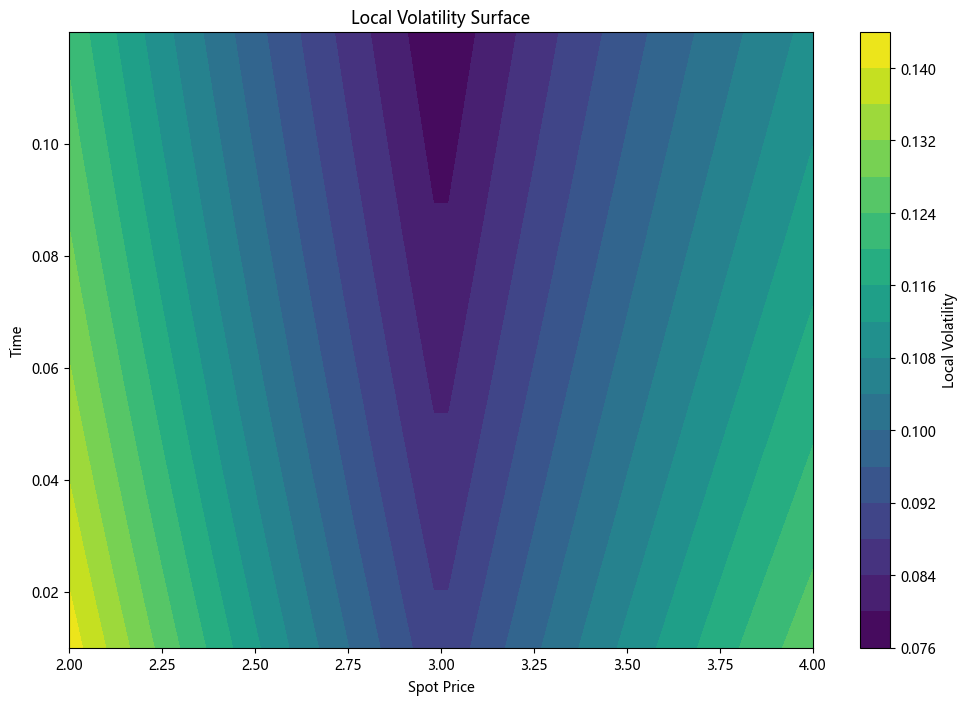

In [8]:
# 设置参数
n_training_paths = 1000  # 减少路径数以加快调试
n_time_steps = 30
time_step = 1 / 250
initial_price = 3.0
initial_state = (initial_price,)

# 定义局部波动率函数
def local_vol_function(time: torch.Tensor, spot: torch.Tensor) -> torch.Tensor:
    """创建明显的波动率微笑和期限结构"""
    # 防止除零
    time = torch.clamp(time, min=1e-6)
    
    # 更明显的微笑效应
    moneyness = spot / initial_price
    smile_effect = 0.2 + 0.3 * (moneyness.log().abs())
    
    # 期限结构
    time_effect = 1.0 + 0.5 * torch.exp(-5 * time)
    
    # 基础波动率
    base_vol = 0.3
    
    return base_vol * smile_effect * time_effect

# 可视化局部波动率曲面
print("生成局部波动率曲面可视化...")
spot_range = torch.linspace(2.0, 4.0, 50)
time_range = torch.linspace(0.01, time_step * n_time_steps, 50)
spot_grid, time_grid = torch.meshgrid(spot_range, time_range, indexing='ij')
vol_surface = local_vol_function(time_grid, spot_grid)

plt.figure(figsize=(12, 8))
contour = plt.contourf(spot_grid.numpy(), time_grid.numpy(), vol_surface.numpy(), levels=20, cmap='viridis')
plt.colorbar(contour, label='Local Volatility')
plt.xlabel('Spot Price')
plt.ylabel('Time')
plt.title('Local Volatility Surface')
plt.show()

In [17]:
n_training_paths = 1000
n_time_steps = 30
time_step = 1 / 250
initial_price = 3.0
sigma = 0.3  # 常数波动率
strike_price = 3.0
time_to_maturity = n_time_steps * time_step
feature_list = ["log_moneyness", "expiry_time", "volatility", "prev_hedge"]
transaction_cost = 0.001
training_epochs = 100

time_to_maturity = n_time_steps * time_step
feature_list = ["log_moneyness", "expiry_time", "volatility", "prev_hedge"]

# 创建一个临时的局部波动率股票用于训练
temp_lv_stock = LocalVolatilityStock(transaction_cost, time_step, local_vol_function)
temp_option1 = EuropeanOption(temp_lv_stock, strike=strike_price, maturity=time_to_maturity)

temp_gbm_stock = BrownianStock(transaction_cost, time_step, sigma)
temp_option2 = EuropeanOption(temp_gbm_stock, strike=strike_price, maturity=time_to_maturity)

# 风险度量
risk_measures = {
    "Entropic Risk (a=1.0)": EntropicRiskMeasure(a=1.0),
    "Entropic Risk (a=0.1)": EntropicRiskMeasure(a=0.1),
    "Expected Shortfall (95%)": ExpectedShortfall(0.05),
    "Expected Shortfall (50%)": ExpectedShortfall(0.5),
}

# 训练对冲器
print("\n开始训练对冲器（使用局部波动率数据）...")
trained_hedgers = {}

# Black-Scholes（用于对比）
bs_hedger = BlackScholes(temp_option)
trained_hedgers["Black-Scholes"] = {
    "model": bs_hedger,
    "type": "black_scholes",
    "features": None
}

# 神经网络对冲器
for risk_name, risk_measure in risk_measures.items():
    print(f"\n用Local Volatility训练 {risk_name}...")
    nn_hedger = create_lv_hedger(
        risk_measure,
        temp_option1,
        feature_list,
        training_epochs,
        n_training_paths,
        initial_price,
        local_vol_function
    )
    trained_hedgers["Local Volatility + "+risk_name] = {
        "model": nn_hedger,
        "type": "neural_network", 
        "features": feature_list
    }

print("\n开始训练对冲器（使用几何布朗运动数据）...")
for risk_name, risk_measure in risk_measures.items():
    print(f"\n用Brownian Motion训练 {risk_name}...")
    nn_hedger = create_gbm_hedger(
        risk_measure,
        temp_option2,
        feature_list,
        training_epochs,
        n_training_paths,
        initial_price,
        sigma
    )
    trained_hedgers["Brownian Motion + "+risk_name] = {
        "model": nn_hedger,
        "type": "neural_network", 
        "features": feature_list
    }


开始训练对冲器（使用局部波动率数据）...

用Local Volatility训练 Entropic Risk (a=1.0)...
  开始训练，总共 100 个 epochs...
  Epoch 20/100, Loss: 0.035135
  Epoch 40/100, Loss: 0.033715
  Epoch 60/100, Loss: 0.035323
  Epoch 80/100, Loss: 0.034066
  Epoch 100/100, Loss: 0.033337

用Local Volatility训练 Entropic Risk (a=0.1)...
  开始训练，总共 100 个 epochs...
  Epoch 20/100, Loss: 0.032778
  Epoch 40/100, Loss: 0.029149
  Epoch 60/100, Loss: 0.032806
  Epoch 80/100, Loss: 0.033951
  Epoch 100/100, Loss: 0.030766

用Local Volatility训练 Expected Shortfall (95%)...
  开始训练，总共 100 个 epochs...
  Epoch 20/100, Loss: 0.105290
  Epoch 40/100, Loss: 0.104154
  Epoch 60/100, Loss: 0.104245
  Epoch 80/100, Loss: 0.097066
  Epoch 100/100, Loss: 0.104098

用Local Volatility训练 Expected Shortfall (50%)...
  开始训练，总共 100 个 epochs...
  Epoch 20/100, Loss: 0.066128
  Epoch 40/100, Loss: 0.054953
  Epoch 60/100, Loss: 0.054839
  Epoch 80/100, Loss: 0.055778
  Epoch 100/100, Loss: 0.054401

开始训练对冲器（使用几何布朗运动数据）...

用Brownian Motion训练 Entropic Risk (

In [18]:
# 评估性能
print("\n评估对冲器性能（使用新的局部波动率路径）...")
n_test_paths = 1000
performance_results = {}

for hedger_name, hedger_data in trained_hedgers.items():
    print(f"评估 {hedger_name}...")
    
    # 创建测试用的局部波动率股票
    test_lv_stock = LocalVolatilityStock(transaction_cost, time_step, local_vol_function)
    test_option = EuropeanOption(test_lv_stock, strike=strike_price, maturity=time_to_maturity)
    
    # 模拟测试路径
    test_option.simulate(n_paths=n_test_paths, init_state=(initial_price,))
    
    # 计算损益
    pnl = compute_lv_pnl(
        hedger_data["model"],
        test_option,
        hedger_data["features"],
        is_black_scholes=(hedger_data["type"] == "black_scholes")
    )
    
    performance_results[hedger_name] = pnl


评估对冲器性能（使用新的局部波动率路径）...
评估 Black-Scholes...
评估 Local Volatility + Entropic Risk (a=1.0)...
评估 Local Volatility + Entropic Risk (a=0.1)...
评估 Local Volatility + Expected Shortfall (95%)...
评估 Local Volatility + Expected Shortfall (50%)...
评估 Brownian Motion + Entropic Risk (a=1.0)...
评估 Brownian Motion + Entropic Risk (a=0.1)...
评估 Brownian Motion + Expected Shortfall (95%)...
评估 Brownian Motion + Expected Shortfall (50%)...


In [21]:
# 统计结果
print("\n损益统计:")
print("-" * 100)
print(f"{'策略名称':30s} | {'均值':>10s} | {'标准差':>10s} | {'Sharpe':>8s} | {'95% VaR':>10s} | {'最大损失':>10s}")
print("-" * 100)

for name, pnl in performance_results.items():
    mean_pnl = pnl.mean().item()
    std_pnl = pnl.std().item()
    sharpe = mean_pnl / std_pnl if std_pnl > 0 else 0
    var_95 = torch.quantile(pnl, 0.05).item()
    max_loss = pnl.min().item()
    print(f"{name:30s} | {mean_pnl:10.6f} | {std_pnl:10.6f} | {sharpe:8.3f} | {var_95:10.6f} | {max_loss:10.6f}")


损益统计:
----------------------------------------------------------------------------------------------------
策略名称                           |         均值 |        标准差 |   Sharpe |    95% VaR |       最大损失
----------------------------------------------------------------------------------------------------
Black-Scholes                  |  -0.034514 |   0.005637 |   -6.123 |  -0.043604 |  -0.055054
Local Volatility + Entropic Risk (a=1.0) |  -0.033850 |   0.028502 |   -1.188 |  -0.091838 |  -0.171837
Local Volatility + Entropic Risk (a=0.1) |  -0.038955 |   0.069170 |   -0.563 |  -0.182801 |  -0.364252
Local Volatility + Expected Shortfall (95%) |  -0.033133 |   0.025826 |   -1.283 |  -0.084515 |  -0.148937
Local Volatility + Expected Shortfall (50%) |  -0.035688 |   0.028112 |   -1.269 |  -0.091056 |  -0.151862
Brownian Motion + Entropic Risk (a=1.0) |  -0.033829 |   0.025994 |   -1.301 |  -0.086814 |  -0.149196
Brownian Motion + Entropic Risk (a=0.1) |  -0.034266 |   0.037690 |   -0.909 |

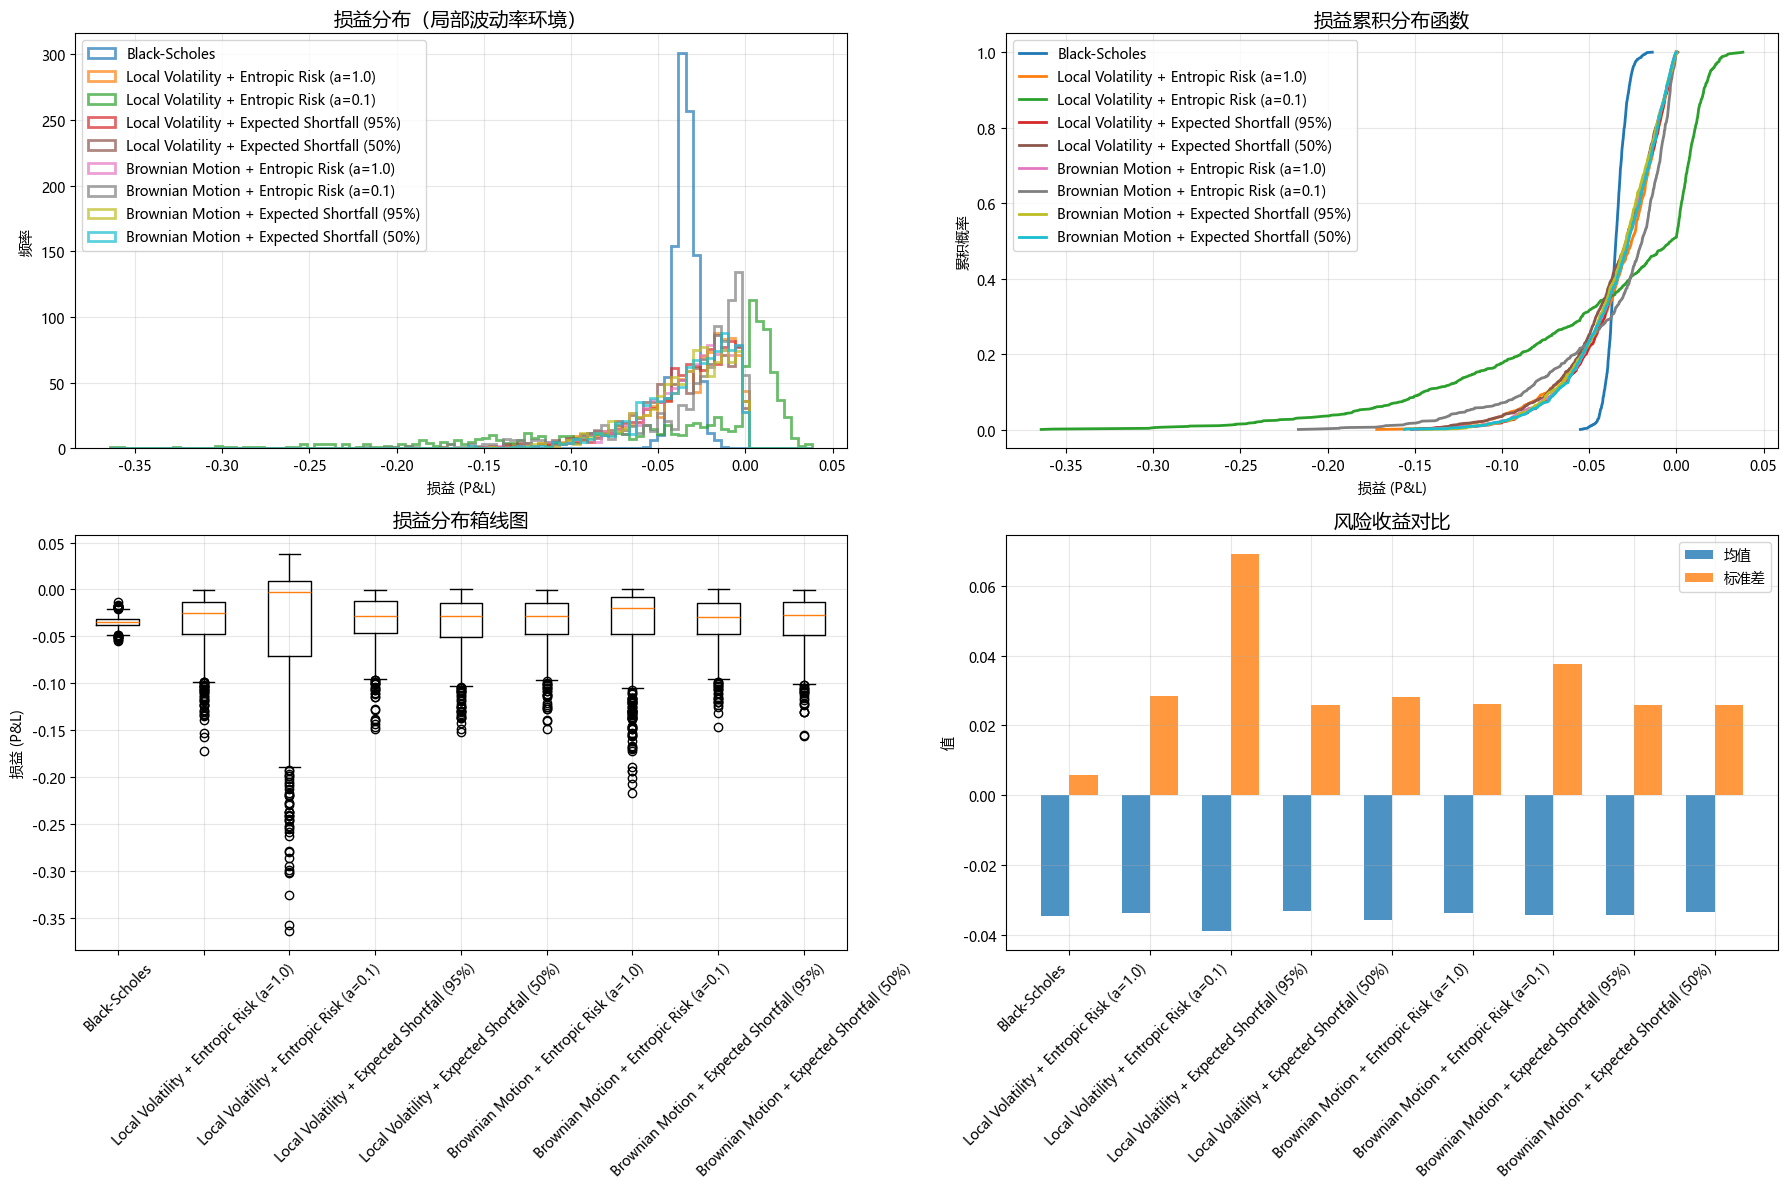

In [22]:
# 可视化结果
fig = plt.figure(figsize=(18, 12))

# 子图1：损益分布
ax1 = plt.subplot(2, 2, 1)
all_pnls = torch.cat([pnl for pnl in performance_results.values()]).detach().numpy()
hist_bins = np.linspace(all_pnls.min(), all_pnls.max(), 101)

colors = plt.cm.tab10(np.linspace(0, 1, len(performance_results)))
for (name, pnl), color in zip(performance_results.items(), colors):
    ax1.hist(pnl.detach().numpy(), bins=hist_bins, label=name, 
             histtype="step", alpha=0.7, linewidth=2, color=color)

ax1.set_title("损益分布（局部波动率环境）", fontsize=14)
ax1.set_xlabel("损益 (P&L)")
ax1.set_ylabel("频率")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 子图2：累积分布
ax2 = plt.subplot(2, 2, 2)
for (name, pnl), color in zip(performance_results.items(), colors):
    sorted_pnl = torch.sort(pnl).values.detach().numpy()
    cumulative_prob = np.arange(1, len(sorted_pnl) + 1) / len(sorted_pnl)
    ax2.plot(sorted_pnl, cumulative_prob, label=name, linewidth=2, color=color)

ax2.set_title("损益累积分布函数", fontsize=14)
ax2.set_xlabel("损益 (P&L)")
ax2.set_ylabel("累积概率")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 子图3：箱线图
ax3 = plt.subplot(2, 2, 3)
pnl_data = [pnl.detach().numpy() for pnl in performance_results.values()]
ax3.boxplot(pnl_data, tick_labels=list(performance_results.keys()))  # 改为 tick_labels
ax3.set_title("损益分布箱线图", fontsize=14)
ax3.set_ylabel("损益 (P&L)")
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# 子图4：风险指标对比
ax4 = plt.subplot(2, 2, 4)
strategies = list(performance_results.keys())
means = [performance_results[s].mean().item() for s in strategies]
stds = [performance_results[s].std().item() for s in strategies]

x = np.arange(len(strategies))
width = 0.35

bars1 = ax4.bar(x - width/2, means, width, label='均值', alpha=0.8)
bars2 = ax4.bar(x + width/2, stds, width, label='标准差', alpha=0.8)

ax4.set_title("风险收益对比", fontsize=14)
ax4.set_ylabel("值")
ax4.set_xticks(x)
ax4.set_xticklabels(strategies, rotation=45, ha='right')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



生成样本路径展示...


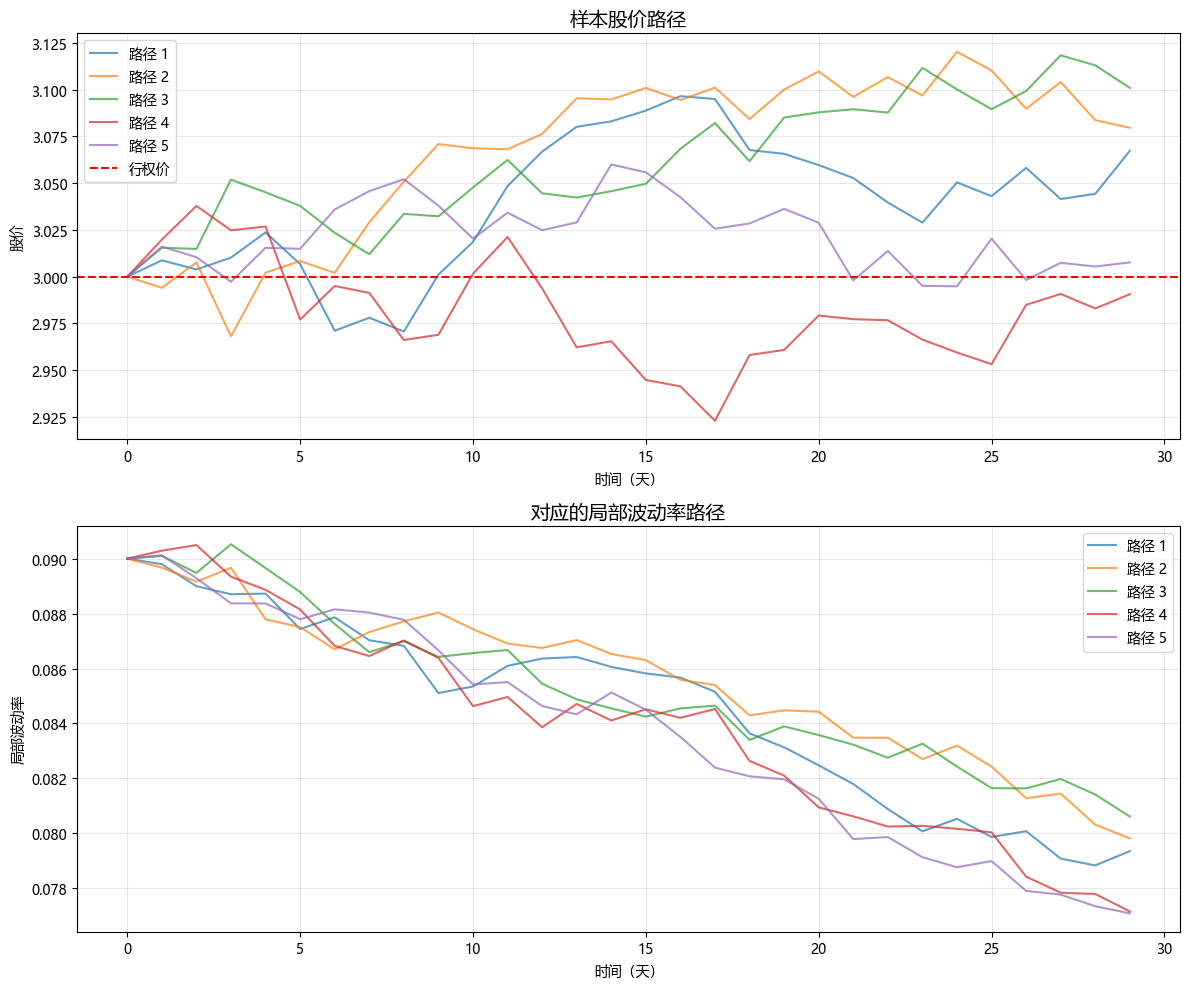

In [16]:
# 展示样本路径
print("\n生成样本路径展示...")
sample_paths = 5
sample_stock = LocalVolatilityStock(transaction_cost, time_step, local_vol_function)
sample_stock.simulate(n_paths=sample_paths, time_horizon=time_to_maturity, init_state=(initial_price,))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 股价路径
time_points = np.arange(sample_stock.spot.shape[1]) * time_step * 250  # 转换为天数
for i in range(sample_paths):
    ax1.plot(time_points, sample_stock.spot[i].numpy(), alpha=0.7, label=f'路径 {i+1}')
ax1.axhline(y=strike_price, color='r', linestyle='--', label='行权价')
ax1.set_title("样本股价路径", fontsize=14)
ax1.set_xlabel("时间（天）")
ax1.set_ylabel("股价")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 对应的局部波动率
# 注意：volatility 的长度比 spot 少 1，因为它代表每个时间步之间的波动率
time_points_vol = np.arange(sample_stock.volatility.shape[1]) * time_step * 250  # 修正：使用 volatility 的实际长度
for i in range(sample_paths):
    ax2.plot(time_points_vol, sample_stock.volatility[i].numpy(), alpha=0.7, label=f'路径 {i+1}')
ax2.set_title("对应的局部波动率路径", fontsize=14)
ax2.set_xlabel("时间（天）")
ax2.set_ylabel("局部波动率")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()